# Heart Failure 30-Day Readmission Prediction

**Month 1 Project — Classification, model comparison, and overfitting/underfitting diagnosis**

This notebook follows the supplied project brief: explore and clean the dataset, check for leakage, create a stratified train/test split, train Logistic Regression, KNN and Decision Tree models, evaluate them using multiple metrics, run controlled hyperparameter experiments with cross-validation, and diagnose generalization.

## 1. Problem statement

Predict whether a heart-failure patient is readmitted within 30 days.

The target is `Readmitted_30_Days`:
- `0` = not readmitted within 30 days
- `1` = readmitted within 30 days

`Patient_ID` is an identifier and is excluded from modeling because it does not represent a clinical predictor.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

DATA_PATH = "/content/dataset_12000_records.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,...,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days
0,PT_00001,65,Female,25.564766,No,No,0,1,0,0,...,95.586026,118.407920,13,0,1,1,1,0,0,0
1,PT_00002,83,Male,30.503110,Yes,Yes,1,1,1,1,...,142.445450,421.440746,4,1,1,1,1,1,1,1
2,PT_00003,76,Male,21.934792,No,No,0,1,1,1,...,158.669171,240.351673,5,0,0,1,1,0,1,0
3,PT_00004,72,Female,22.048039,No,Yes,0,0,1,0,...,145.531173,334.414121,13,0,1,1,1,1,0,1
4,PT_00005,54,Male,27.102739,No,No,3,0,0,0,...,94.644198,71.006274,5,1,1,0,1,0,0,0


## 2. Dataset exploration and data quality

In [7]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Readmitted_30_Days"].value_counts().rename_axis("class").to_frame("count"))

print("\nTarget proportions:")
display(df["Readmitted_30_Days"].value_counts(normalize=True).rename_axis("class").to_frame("proportion"))

print("\nNumeric summary:")
display(df.describe().T.round(2))

Shape: (12000, 36)

Data types:


,dtype
Patient_ID,object
Age,int64
Gender,object
BMI,float64
Smoking_Status,object
Alcohol_Consumption,object
Exercise_Frequency,int64
Hypertension,int64
Diabetes,int64
Chronic_Kidney_Disease,int64



Missing values:


,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Exercise_Frequency,0
Hypertension,0
Diabetes,0
Chronic_Kidney_Disease,0



Duplicate rows: 0

Target distribution:


,count
class,
0,8400
1,3600



Target proportions:


,proportion
class,
0,0.7
1,0.3



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Age,12000.0,67.40,13.08,30.00,60.00,68.00,77.00,95.00
BMI,12000.0,27.79,5.04,16.00,24.30,27.78,31.25,45.98
Exercise_Frequency,12000.0,1.02,1.04,0.00,0.00,1.00,2.00,4.00
Hypertension,12000.0,0.41,0.49,0.00,0.00,0.00,1.00,1.00
Diabetes,12000.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
Chronic_Kidney_Disease,12000.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Coronary_Artery_Disease,12000.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
Previous_Stroke,12000.0,0.18,0.39,0.00,0.00,0.00,0.00,1.00
Atrial_Fibrillation,12000.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00
Previous_HF_Admissions,12000.0,0.63,0.87,0.00,0.00,0.00,1.00,7.00


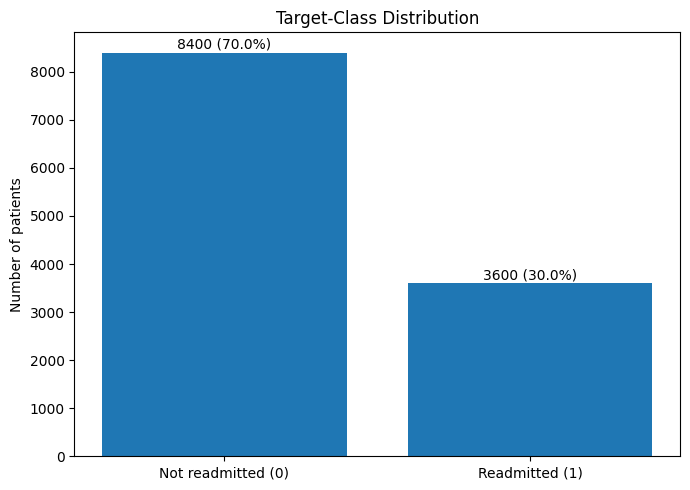

In [8]:
# Target-class visualization
counts = df["Readmitted_30_Days"].value_counts().sort_index()
plt.figure(figsize=(7,5))
bars = plt.bar(["Not readmitted (0)", "Readmitted (1)"], counts.values)
plt.title("Target-Class Distribution")
plt.ylabel("Number of patients")
for b, v in zip(bars, counts.values):
    plt.text(b.get_x()+b.get_width()/2, v+80, f"{v} ({v/len(df):.1%})", ha="center")
plt.tight_layout()
plt.show()

### Data-quality and leakage decisions

- No missing values are present in this supplied dataset, but the modeling pipelines still contain imputers so the workflow remains robust and reproducible.
- No duplicate rows are present.
- `Patient_ID` is excluded because it is an identifier.
- The remaining variables describe patient characteristics, history, clinical measurements, hospitalization information, and medications.
- The target represents the future 30-day readmission outcome. Predictors are retained only under the assumption that they are available at the prediction point. In a real hospital deployment, the exact timestamp/availability of each feature must be audited to prevent temporal leakage.

In [9]:
target = "Readmitted_30_Days"
id_col = "Patient_ID"

X = df.drop(columns=[target, id_col])
y = df[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Number of numeric columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Categorical columns: ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Heart_Failure_Type']
Number of numeric columns: 30
Number of categorical columns: 4


## 3. Preprocessing and fair train/test split

Categorical variables are one-hot encoded. Numeric variables use median imputation and standardization for Logistic Regression and KNN. Decision Trees do not require feature scaling, so its numeric branch is not standardized.

All preprocessing is inside scikit-learn pipelines. Therefore, imputation, scaling, and one-hot encoding are fitted using the training folds only, avoiding data leakage.

The split is 80/20, stratified by the binary target, with `random_state=42` for reproducibility.

In [10]:
scaled_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training class balance:")
display(y_train.value_counts(normalize=True).rename("proportion"))
print("Test class balance:")
display(y_test.value_counts(normalize=True).rename("proportion"))

Training rows: 9600
Test rows: 2400
Training class balance:


,proportion
Readmitted_30_Days,
0,0.7
1,0.3


Test class balance:


,proportion
Readmitted_30_Days,
0,0.7
1,0.3


## 4. Hyperparameter experiments

The project brief recommends controlled experiments rather than arbitrary settings. Model selection is performed using **5-fold stratified cross-validation on the training set**, with ROC-AUC as the selection metric.

- Logistic Regression: compare `C`
- KNN: compare `k`
- Decision Tree: compare `max_depth` and `min_samples_leaf`

The final test set is not used for hyperparameter selection.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
knn_pipe = Pipeline([
    ("prep", scaled_preprocessor),
    ("model", KNeighborsClassifier())
])
dt_pipe = Pipeline([
    ("prep", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

lr_grid = GridSearchCV(
    lr_pipe, {"model__C": [0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1
)
knn_grid = GridSearchCV(
    knn_pipe, {"model__n_neighbors": [3, 5, 9, 15, 21, 31]},
    scoring="roc_auc", cv=cv, n_jobs=-1
)
dt_grid = GridSearchCV(
    dt_pipe,
    {"model__max_depth": [3, 5, 7, 10, None],
     "model__min_samples_leaf": [1, 5, 10]},
    scoring="roc_auc", cv=cv, n_jobs=-1
)

lr_grid.fit(X_train, y_train)
knn_grid.fit(X_train, y_train)
dt_grid.fit(X_train, y_train)

print("Best Logistic Regression:", lr_grid.best_params_, "CV ROC-AUC:", round(lr_grid.best_score_, 4))
print("Best KNN:", knn_grid.best_params_, "CV ROC-AUC:", round(knn_grid.best_score_, 4))
print("Best Decision Tree:", dt_grid.best_params_, "CV ROC-AUC:", round(dt_grid.best_score_, 4))

Best Logistic Regression: {'model__C': 1} CV ROC-AUC: 0.9522
Best KNN: {'model__n_neighbors': 31} CV ROC-AUC: 0.9227
Best Decision Tree: {'model__max_depth': 7, 'model__min_samples_leaf': 10} CV ROC-AUC: 0.8846


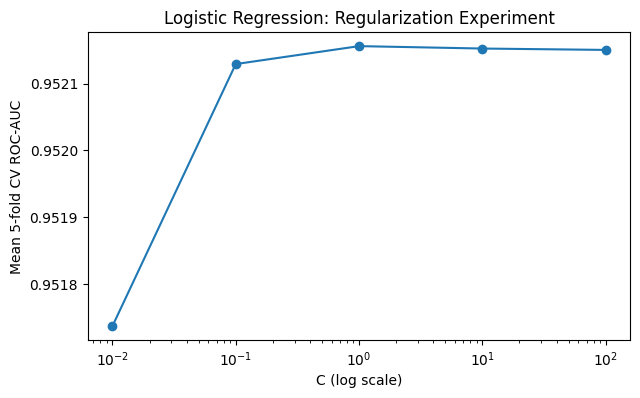

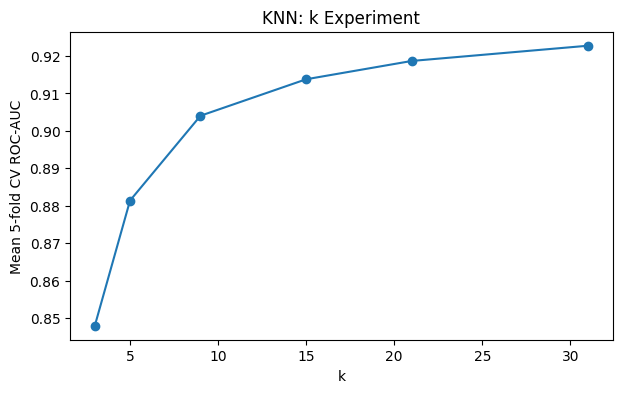

In [12]:
# Plot two key hyperparameter experiments
lr_cv = pd.DataFrame(lr_grid.cv_results_)
plt.figure(figsize=(7,4))
plt.plot(lr_cv["param_model__C"].astype(float), lr_cv["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Mean 5-fold CV ROC-AUC")
plt.title("Logistic Regression: Regularization Experiment")
plt.show()

knn_cv = pd.DataFrame(knn_grid.cv_results_)
plt.figure(figsize=(7,4))
plt.plot(knn_cv["param_model__n_neighbors"].astype(int), knn_cv["mean_test_score"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean 5-fold CV ROC-AUC")
plt.title("KNN: k Experiment")
plt.show()

## 5. Train the three final models

The selected estimators below are the best estimators from cross-validation. They are all evaluated on the same untouched test set.

In [13]:
models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_
}

def get_metrics(model, X_data, y_data):
    pred = model.predict(X_data)
    prob = model.predict_proba(X_data)[:, 1]
    return {
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred, zero_division=0),
        "Recall": recall_score(y_data, pred, zero_division=0),
        "F1": f1_score(y_data, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_data, prob)
    }

rows = []
cms = {}

for name, model in models.items():
    train_m = get_metrics(model, X_train, y_train)
    test_m = get_metrics(model, X_test, y_test)
    cm = confusion_matrix(y_test, model.predict(X_test))
    cms[name] = cm
    rows.append({
        "Model": name,
        "Train Accuracy": train_m["Accuracy"],
        "Test Accuracy": test_m["Accuracy"],
        "Precision": test_m["Precision"],
        "Recall": test_m["Recall"],
        "F1": test_m["F1"],
        "ROC-AUC": test_m["ROC-AUC"],
        "Train ROC-AUC": train_m["ROC-AUC"],
        "TN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "TP": cm[1,1]
    })

results = pd.DataFrame(rows).set_index("Model")
display(results.round(4))

,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC,Train ROC-AUC,TN,FP,FN,TP
Model,,,,,,,,,,,
Logistic Regression,0.8946,0.8950,0.8524,0.7861,0.8179,0.9562,0.9537,1582,98,154,566
KNN,0.8547,0.8496,0.8811,0.5764,0.6969,0.9271,0.9398,1624,56,305,415
Decision Tree,0.8747,0.8392,0.7530,0.6903,0.7203,0.8948,0.9315,1517,163,223,497


## 6. Confusion matrices

For this problem:
- **TP:** patient predicted readmitted and actually readmitted.
- **TN:** patient predicted not readmitted and actually not readmitted.
- **FP:** patient predicted readmitted but not actually readmitted.
- **FN:** patient predicted not readmitted but actually readmitted.

False negatives are particularly important to inspect because they represent patients whose 30-day readmission risk was missed.

<Figure size 500x400 with 0 Axes>

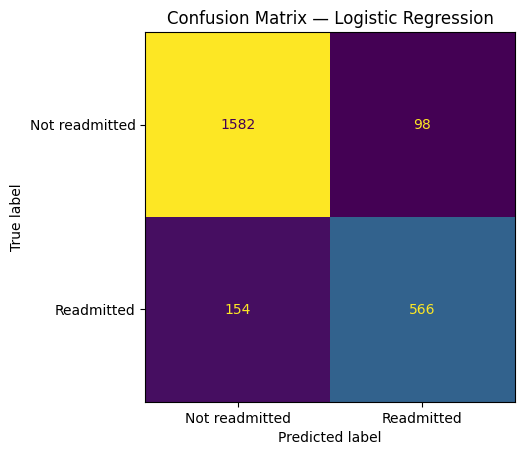

<Figure size 500x400 with 0 Axes>

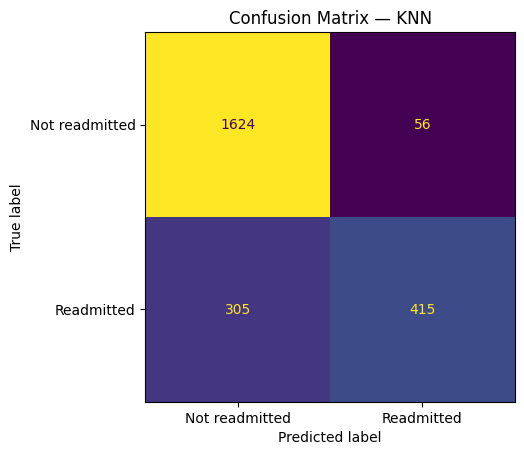

<Figure size 500x400 with 0 Axes>

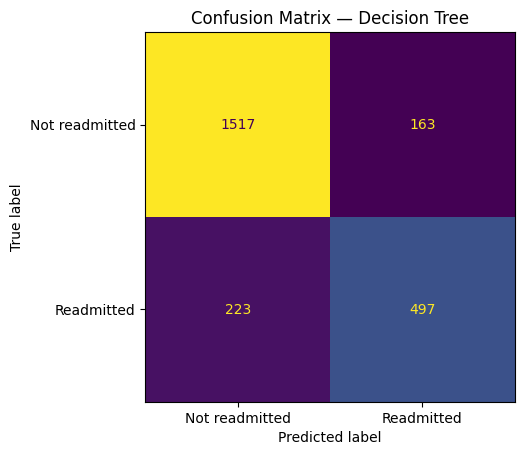

In [14]:
for name, cm in cms.items():
    plt.figure(figsize=(5,4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not readmitted", "Readmitted"])
    disp.plot(values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

## 7. Required visual comparisons

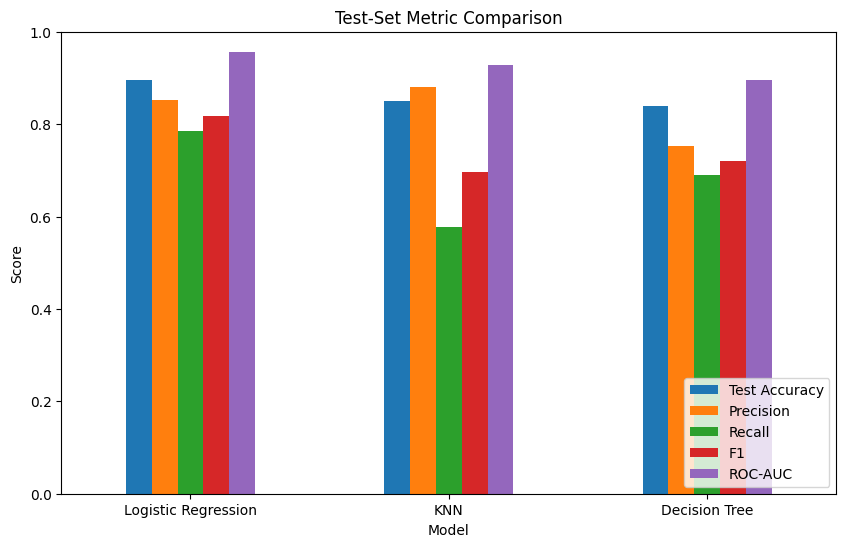

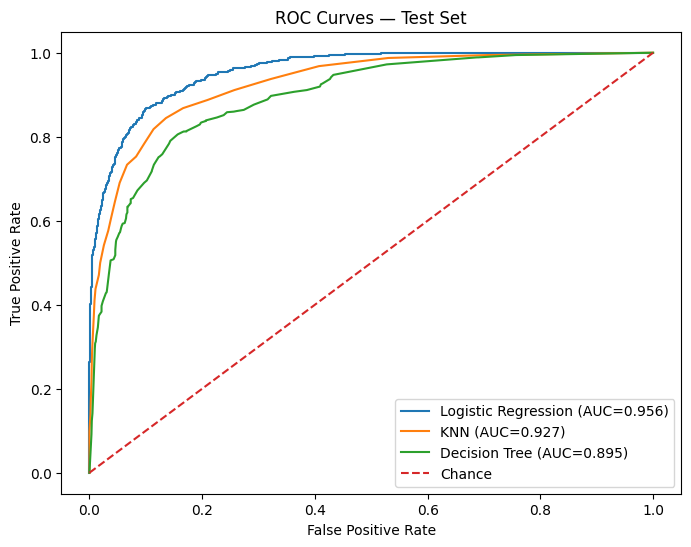

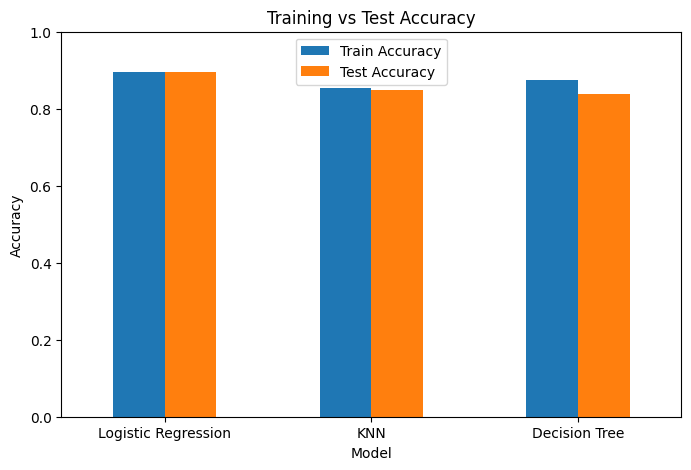

In [15]:
metric_cols = ["Test Accuracy","Precision","Recall","F1","ROC-AUC"]
results[metric_cols].plot(kind="bar", figsize=(10,6))
plt.ylim(0,1)
plt.title("Test-Set Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(8,6))
for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.show()

results[["Train Accuracy","Test Accuracy"]].plot(kind="bar", figsize=(8,5))
plt.ylim(0,1)
plt.title("Training vs Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

## 8. Overfitting / underfitting diagnosis

A high training score alone is not enough to call a model overfit. The diagnosis below considers the train/test gap and the absolute test performance.

For this dataset:
- **Logistic Regression:** training accuracy ≈ 0.895 and test accuracy ≈ 0.895, with very similar ROC-AUC values. This is evidence of good generalization rather than a large fit gap.
- **KNN:** training accuracy ≈ 0.855 and test accuracy ≈ 0.850. The gap is small; the results do not provide strong evidence of overfitting.
- **Decision Tree:** training accuracy ≈ 0.875 and test accuracy ≈ 0.839. The larger gap indicates a mild generalization problem consistent with some overfitting, although the tree was already constrained by depth and minimum leaf size.
- No model shows the classic pattern of very low training and test performance, so there is no strong evidence of severe underfitting.



## 9. Q1–Q14: written analysis

**Q1. What is the class distribution?**  
The target contains 8,400 class-0 records (70%) and 3,600 class-1 records (30%). The data are moderately imbalanced, so accuracy alone can hide poor performance on the minority readmission class.

**Q2. What preprocessing was performed?**  
`Patient_ID` was excluded as an identifier. Categorical variables were one-hot encoded. Numeric variables were median-imputed and standardized for Logistic Regression and KNN. The Decision Tree used imputation and one-hot encoding without scaling. Because preprocessing is inside pipelines, fitting occurs on training data/folds only.

**Q3. Why is KNN more sensitive to scaling?**  
KNN uses distances between observations. A feature with a larger numeric scale can dominate the distance calculation. Standardization puts numeric variables on comparable scales. Logistic Regression does not use Euclidean distance, so scaling is less critical for its basic correctness, although it can improve optimization and make regularization act more consistently across features.

**Q4. What k was used and how was it selected?**  
Cross-validation compared k = 3, 5, 9, 15, 21 and 31 using ROC-AUC. The selected value was **k = 31**. Very small k values can be sensitive to individual observations and produce high-variance decision boundaries; very large k values smooth the boundary too much and can lose local structure.

**Q5. What Decision Tree settings were used?**  
Cross-validation selected **max_depth = 7** and **min_samples_leaf = 10**. Limiting depth and requiring a minimum number of observations per leaf reduces overly specific branches and can improve generalization.

**Q6. Compare the three models.**  
Logistic Regression achieved the strongest overall test metrics in this dataset: accuracy ≈ 0.895, precision ≈ 0.852, recall ≈ 0.786, F1 ≈ 0.818 and ROC-AUC ≈ 0.956. KNN had higher precision but lower recall, while the Decision Tree had lower overall test ROC-AUC and F1. The conclusion is based on multiple metrics and the healthcare context, not accuracy alone.

**Q7. Which metric deserves the most attention?**  
The priority depends on the operational consequences of false positives and false negatives. If the hospital mainly wants to avoid missing patients who need follow-up, recall is especially important because it measures the fraction of actual readmissions detected. Precision matters when follow-up resources are limited. In practice, the threshold should be selected with clinical and resource considerations rather than blindly using 0.5.

**Q8. Does any model appear overfit?**  
The Decision Tree shows the clearest gap: about 0.875 training accuracy versus 0.839 test accuracy. This is evidence of some overfitting/generalization loss. Logistic Regression and KNN have much smaller accuracy gaps.

**Q9. Does any model appear underfit?**  
There is no strong evidence of severe underfitting. None has both very low training and very low test performance. KNN is weaker than Logistic Regression on several test metrics, but that alone is not sufficient to label it underfit.

**Q10. How could overfitting be reduced?**  
For the Decision Tree: (1) reduce `max_depth`, (2) increase `min_samples_leaf` or `min_samples_split`, and (3) use cross-validation/pruning or feature selection. These changes restrict overly specific decision rules.

**Q11. How could underfitting be improved?**  
If a future model shows underfitting, possible changes include reducing excessive regularization, increasing model capacity, and engineering more informative features. For KNN specifically, testing a smaller k can increase local model flexibility, while for Logistic Regression a less restrictive regularization setting can allow a richer linear decision boundary.

**Q12. Is highest accuracy automatically best?**  
No. A model can have good accuracy while missing many positive cases, especially with class imbalance. Precision, recall, F1 and ROC-AUC provide additional evidence. The supplied results demonstrate that model selection should consider the full metric profile.

**Q13. If ROC-AUC is similar but precision/recall differ, which would you choose?**  
The choice should depend on the operational cost of errors. If missing a true readmission is more costly, the model/threshold with higher recall may be preferred; if unnecessary interventions are costly, higher precision may matter more. The threshold can also be adjusted without retraining the model.

**Q14. What are limitations before deployment?**  
At least three major limitations are: (1) this is a single supplied dataset and may not represent other hospitals or populations; (2) feature availability timestamps must be audited to rule out temporal leakage; and (3) performance metrics do not establish clinical utility, fairness, calibration, or safety. External validation and prospective evaluation would be needed before real-world use.



## 10. Final evidence-based conclusion

On this supplied dataset, **Logistic Regression** has the strongest overall test performance across the required metrics and shows a very small train/test accuracy gap. The Decision Tree has a larger generalization gap, while KNN trades higher precision for lower recall.

This is a model-development conclusion for the supplied dataset, not a claim that the model is ready for clinical deployment. A real deployment would require temporal leakage auditing, external validation, calibration, fairness analysis, clinical review, monitoring, and prospective evaluation.